# Обучение модели ResNet18 для классификации AI vs Human Generated Images

Этот notebook содержит код для обучения модели ResNet18 на датасете Train_1 и оценки качества на Test_1.

## 1. Импорт библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import boto3
from botocore.client import Config
import json
import os
import yaml

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Подготовка данных

In [42]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.root_dir / self.data.iloc[idx]['file_name']
        if not img_path.exists():
            img_path = Path(str(img_path).replace('train_data', 'test_data'))
        img = Image.open(img_path).convert('RGB')
        lbl = self.data.iloc[idx]['label']
        return (self.transform(img) if self.transform else img), lbl

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Train_1/train.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Train_1',
    transform=train_transform
)

test_dataset = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Test_1/test.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Test_1',
    transform=test_transform
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 9993
Test dataset size: 3997


## 3. Создание модели ResNet18

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

## 4. Определение функции потерь и оптимизатора

In [9]:
lr = 0.001
num_epochs = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

## 5. Функция обучения

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_acc, epoch_f1

## 6. Функция валидации

In [11]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    epoch_precision = precision_score(all_labels, all_preds, average='weighted')
    epoch_recall = recall_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

## 7. Обучение модели

In [12]:
# TensorBoard
writer = SummaryWriter(log_dir='my_logs/train_v1')

hparams_train = {
    'model': 'ResNet18',
    'optimizer': 'Adam',
    'lr': lr,
    'batch_size': batch_size,
    'num_epochs': num_epochs,
    'scheduler': 'StepLR(step_size=5, gamma=0.1)'
}
writer.add_text('Hyperparameters/train', str(hparams_train), global_step=0)
print('Hyperparameters logged to TensorBoard')
print(hparams_train)

# Обучение
train_losses, train_accs, train_f1s = [], [], []

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('F1/train', train_f1, epoch)
    writer.add_scalar('LR', scheduler.get_last_lr()[0], epoch)

    print(f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  F1: {train_f1:.4f}')

print('\nTraining done')

Hyperparameters logged to TensorBoard
{'model': 'ResNet18', 'optimizer': 'Adam', 'lr': 0.001, 'batch_size': 32, 'num_epochs': 5, 'scheduler': 'StepLR(step_size=5, gamma=0.1)'}

Epoch 1/5
--------------------------------------------------


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Training: 100%|██████████| 313/313 [43:07<00:00,  8.27s/it]


Train Loss: 0.3792  Acc: 0.8379  F1: 0.8379

Epoch 2/5
--------------------------------------------------


Training: 100%|██████████| 313/313 [43:29<00:00,  8.34s/it]


...

Train Loss: 0.2672  Acc: 0.8910  F1: 0.8910

Epoch 4/5
--------------------------------------------------


Training: 100%|██████████| 313/313 [35:51<00:00,  6.87s/it]


Train Loss: 0.2428  Acc: 0.9057  F1: 0.9057

Epoch 5/5
--------------------------------------------------


Training: 100%|██████████| 313/313 [36:31<00:00,  7.00s/it]

Train Loss: 0.2240  Acc: 0.9098  F1: 0.9098

Training done


## 8. Оценка модели на тестовом датасете

In [16]:
# Добавьте логику оценки модели на тестовом датасете, как метрику в tensorboard
# pip install tensorboard
# команда для поднятия
# tensorboard --logdir=my_logs

test_loss, test_acc, test_f1, test_prec, test_rec = validate(
    model, test_loader, criterion, device
)

print(f'\nTest Results (v1):')
print(f'Loss: {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'F1: {test_f1:.4f}')
print(f'Precision: {test_prec:.4f}')
print(f'Recall: {test_rec:.4f}')

writer.add_scalar('Test/loss', test_loss, 0)
writer.add_scalar('Test/accuracy', test_acc, 0)
writer.add_scalar('Test/f1', test_f1, 0)
writer.add_scalar('Test/precision', test_prec, 0)
writer.add_scalar('Test/recall', test_rec, 0)

writer.add_hparams(
    {'lr': lr, 'batch_size': batch_size, 'num_epochs': num_epochs},
    {'hparam/test_acc': test_acc, 'hparam/test_f1': test_f1}
)

writer.close()

Validation: 100%|██████████| 125/125 [05:23<00:00,  2.59s/it]


Test Results (v1):
Loss: 0.2006
Accuracy: 0.9209
F1: 0.9209
Precision: 0.9222
Recall: 0.9209


In [17]:
S3_ENDPOINT = 'http://localhost:9000'
S3_ACCESS_KEY = 'minioadmin'
S3_SECRET_KEY = 'minioadmin'
BUCKET_NAME = 'models'

s3 = boto3.client(
    's3',
    endpoint_url=S3_ENDPOINT,
    aws_access_key_id=S3_ACCESS_KEY,
    aws_secret_access_key=S3_SECRET_KEY,
    config=Config(signature_version='s3v4'),
    region_name='us-east-1'
)

existing = [b['Name'] for b in s3.list_buckets()['Buckets']]
if BUCKET_NAME not in existing:
    s3.create_bucket(Bucket=BUCKET_NAME)
    print(f'Bucket "{BUCKET_NAME}" created')
else:
    print(f'Bucket "{BUCKET_NAME}" already exists')

Path('models').mkdir(exist_ok=True)
torch.save(model.state_dict(), 'models/model_v1.pth')
s3.upload_file('models/model_v1.pth', BUCKET_NAME, 'resnet18_v1.pth')
print('model_v1.pth uploaded to S3 as resnet18_v1.pth')

Bucket "models" already exists
model_v1.pth uploaded to S3 as resnet18_v1.pth


## 9. Дообучите модель на втором датасете и постройте DVC пайплайн

In [53]:
#!git init
#!dvc init -f
import os
try:
    os.remove(r'.dvc\tmp\rwlock')
except:
    pass
!dvc repro
!dvc dag

Stage 'finetune' didn't change, skipping
Running stage 'evaluate':
> python scripts/evaluate.py
Evaluation results (v2 on Test_2):
  loss: 0.0513
  accuracy: 0.9840
  f1: 0.9840
  precision: 0.9840
  recall: 0.9840
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add dvc.lock

To enable auto staging, run:

	dvc config core.autostage true
Use `dvc push` to send your updates to remote storage.



Evaluating v2 on Test_2: 100%|██████████| 63/63 [02:51<00:00,  2.72s/it]


+----------+ 
| finetune | 
+----------+ 
      *      
      *      
      *      
+----------+ 
| evaluate | 
+----------+ 


In [54]:
# Показать все метрики (обе стадии)
!dvc metrics show

Path                           accuracy    f1       loss     precision    recall
metrics\finetune_metrics.json  0.96923     0.96923  0.08481  -            -
metrics\test_metrics.json      0.984       0.984    0.05131  0.984        0.984


## 10. Напишите вывод о полученных результатах

Model v1 обучалась на Train_1 в течение 5 эпох с learning rate 0.001 на базе pretrained ResNet18. Loss последовательно снижался с 0.38 до 0.22, accuracy выросла с 0.84 до 0.91 — модель стабильно обучалась. На тестовой выборке Test_1 модель показала accuracy 0.9209, F1 0.9209, precision 0.9222, recall 0.9209, loss 0.2006.

Model v2 — дообучение v1 на Train_2 в течение 2 эпох с уменьшенным learning rate 0.0001. Малый lr позволил адаптироваться к новым данным без потери знаний с Train_1. По итогам дообучения accuracy на Train_2 составила 0.9692, F1 0.9692, loss 0.0848.

Model v2 превосходит v1 по всем метрикам: accuracy выросла с 0.9209 до 0.9840, F1 — с 0.9209 до 0.9840, loss снизился с 0.2006 до 0.0513, то есть на 74%. Дообучение на Train_2 оказалось эффективным даже за 2 эпохи.
DVC пайплайн автоматически воспроизвёл стадии finetune и evaluate.

Немного графиков с tensorboard:

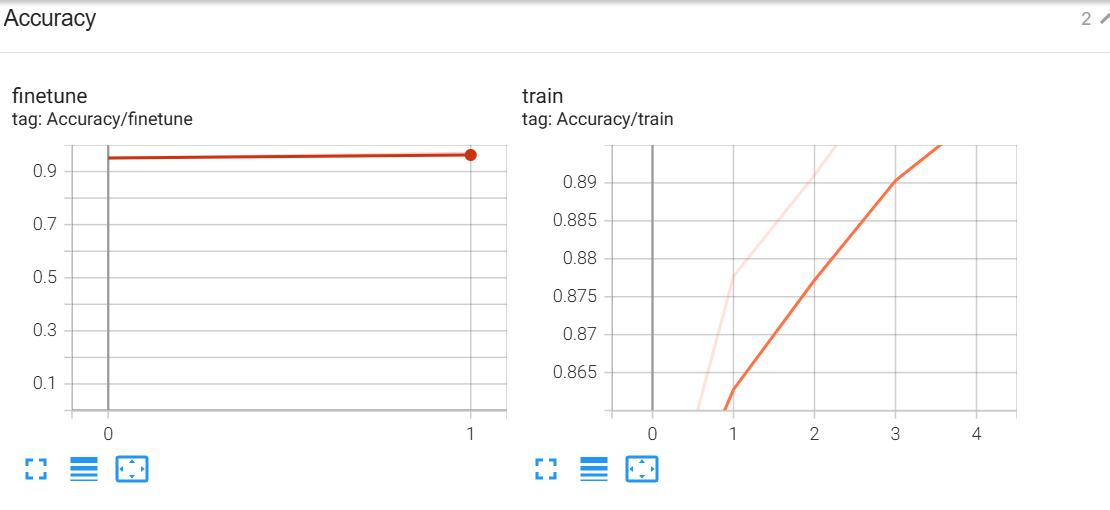

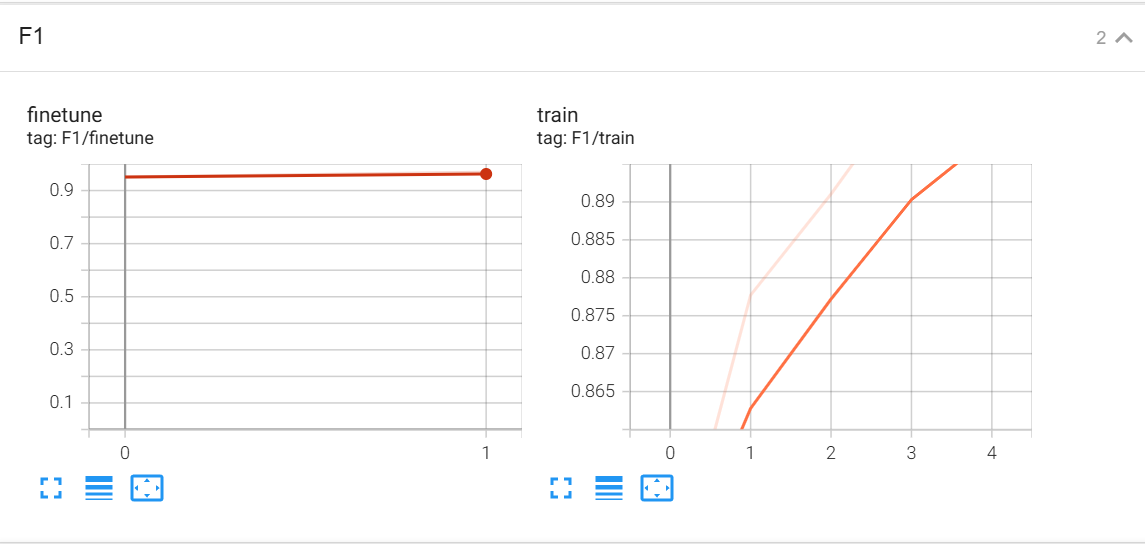